<a href="https://colab.research.google.com/github/tabrejansary/ML-Assignments/blob/main/Lab-05/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BL.SC.U4CSE24070**
# LAB - 5

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()


data = pd.ExcelFile("Lab Session Data.xlsx")

print(data.sheet_names)

df = pd.read_excel(
    "Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

df.head()

Saving Lab Session Data.xlsx to Lab Session Data (1).xlsx
['Purchase data', 'IRCTC Stock Price', 'thyroid0387_UCI', 'marketing_campaign']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [13]:
# A1

import pandas as pd
import numpy as np


def impute_data(data):
    data = data.copy()

    numerical_columns = data.select_dtypes(
        include=np.number
    ).columns

    categorical_columns = data.select_dtypes(
        include=["object", "category"]
    ).columns

    for column in numerical_columns:
        if data[column].isnull().any():
            data[column] = data[column].fillna(
                data[column].mean()
            )

    for column in categorical_columns:
        if data[column].isnull().any():
            data[column] = data[column].fillna(
                data[column].mode()[0]
            )

    return data


def encode_data(data):
    categorical_columns = data.select_dtypes(
        include=["object", "category"]
    ).columns

    data = pd.get_dummies(
        data,
        columns=categorical_columns,
        drop_first=False,
        dtype=int
    )

    return data


def prepare_data(file_path):
    data = pd.read_excel(
        file_path,
        sheet_name="marketing_campaign"
    )

    data = data.copy()

    data["Dt_Customer"] = pd.to_datetime(
        data["Dt_Customer"],
        errors="coerce",
        dayfirst=True
    )

    data["Customer_Year"] = data["Dt_Customer"].dt.year
    data["Customer_Month"] = data["Dt_Customer"].dt.month
    data["Customer_Day"] = data["Dt_Customer"].dt.day

    data.drop(
        columns=["Dt_Customer"],
        inplace=True
    )

    data = impute_data(data)

    labels = data["Response"]

    features = data.drop(
        columns=["Response"]
    )

    features = encode_data(features)

    features = features.astype(float)

    return features, labels


def minkowski_distance(point_a, point_b, p=2):
    return np.sum(
        np.abs(point_a - point_b) ** p
    ) ** (1 / p)


def euclidean_distance(point_a, point_b):
    return minkowski_distance(
        point_a,
        point_b,
        p=2
    )


def manhattan_distance(point_a, point_b):
    return minkowski_distance(
        point_a,
        point_b,
        p=1
    )


def calculate_distance(
    point_a,
    point_b,
    metric="euclidean"
):
    if metric == "euclidean":
        return euclidean_distance(
            point_a,
            point_b
        )

    if metric == "manhattan":
        return manhattan_distance(
            point_a,
            point_b
        )

    if metric == "minkowski":
        return minkowski_distance(
            point_a,
            point_b,
            p=3
        )

    raise ValueError(
        "Invalid distance metric"
    )


def bubble_sort(items):
    result = items.copy()

    for i in range(len(result)):
        for j in range(
            len(result) - i - 1
        ):
            if result[j][0] > result[j + 1][0]:
                result[j], result[j + 1] = (
                    result[j + 1],
                    result[j]
                )

    return result


def selection_sort(items):
    result = items.copy()

    for i in range(len(result)):
        minimum_index = i

        for j in range(i + 1, len(result)):
            if result[j][0] < result[minimum_index][0]:
                minimum_index = j

        result[i], result[minimum_index] = (
            result[minimum_index],
            result[i]
        )

    return result


def insertion_sort(items):
    result = items.copy()

    for i in range(1, len(result)):
        current = result[i]
        j = i - 1

        while (
            j >= 0
            and result[j][0] > current[0]
        ):
            result[j + 1] = result[j]
            j -= 1

        result[j + 1] = current

    return result


def sort_distances(
    distances,
    sorting_algorithm="bubble"
):
    if sorting_algorithm == "bubble":
        return bubble_sort(distances)

    if sorting_algorithm == "selection":
        return selection_sort(distances)

    if sorting_algorithm == "insertion":
        return insertion_sort(distances)

    raise ValueError(
        "Invalid sorting algorithm"
    )


def find_neighbors(
    training_features,
    training_labels,
    test_point,
    k,
    metric="euclidean",
    sorting_algorithm="bubble"
):
    distances = []

    for index in range(
        len(training_features)
    ):
        distance = calculate_distance(
            training_features[index],
            test_point,
            metric
        )

        distances.append(
            (
                distance,
                index,
                training_labels[index]
            )
        )

    distances = sort_distances(
        distances,
        sorting_algorithm
    )

    return distances[:k]


def majority_vote(neighbors):
    class_votes = {}

    for distance, index, label in neighbors:
        class_votes[label] = (
            class_votes.get(label, 0) + 1
        )

    maximum_votes = max(
        class_votes.values()
    )

    candidates = [
        label
        for label, votes in class_votes.items()
        if votes == maximum_votes
    ]

    return min(candidates)

In [4]:
#A2

def weighted_vote(neighbors):
    class_weights = {}

    for distance, index, label in neighbors:

        weight = 1 / (
            distance + 1e-10
        )

        class_weights[label] = (
            class_weights.get(label, 0)
            + weight
        )

    maximum_weight = max(
        class_weights.values()
    )

    candidates = [
        label
        for label, weight in class_weights.items()
        if weight == maximum_weight
    ]

    return min(candidates)


def weighted_class_assignment(neighbors):
    return weighted_vote(neighbors)



In [5]:
#A3

from sklearn.model_selection import train_test_split


def create_train_test_data(
    features,
    labels,
    test_size=0.3,
    random_state=42
):
    return train_test_split(
        features,
        labels,
        test_size=test_size,
        random_state=random_state,
        stratify=labels
    )

In [6]:
# A4

from sklearn.neighbors import KNeighborsClassifier


def train_sklearn_knn(
    x_train,
    y_train,
    k=3
):
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        x_train,
        y_train
    )

    return model



In [7]:
# A5

def calculate_sklearn_accuracy(
    model,
    x_test,
    y_test
):
    return model.score(
        x_test,
        y_test
    )


In [8]:
# A6

def predict_sklearn_knn(
    model,
    x_test
):
    return model.predict(
        x_test
    )


In [18]:
# A7

class CustomKNN:

    def __init__(
        self,
        k=3,
        metric="euclidean",
        sorting_algorithm="merge",
        weighted=False
    ):
        self.k = k
        self.metric = metric
        self.sorting_algorithm = sorting_algorithm
        self.weighted = weighted
        self.x_train = None
        self.y_train = None

    def fit(
        self,
        x_train,
        y_train
    ):
        self.x_train = np.asarray(
            x_train,
            dtype=float
        )

        self.y_train = np.asarray(
            y_train
        )

        return self

    def _merge_sort(self, distances):

        if len(distances) <= 1:
            return distances

        middle = len(distances) // 2

        left = self._merge_sort(
            distances[:middle]
        )

        right = self._merge_sort(
            distances[middle:]
        )

        result = []

        left_index = 0
        right_index = 0

        while (
            left_index < len(left)
            and right_index < len(right)
        ):

            if left[left_index][0] <= right[right_index][0]:
                result.append(
                    left[left_index]
                )
                left_index += 1

            else:
                result.append(
                    right[right_index]
                )
                right_index += 1

        result.extend(
            left[left_index:]
        )

        result.extend(
            right[right_index:]
        )

        return result

    def _calculate_distances(
        self,
        test_point
    ):
        if self.metric == "euclidean":

            differences = (
                self.x_train - test_point
            )

            distances = np.sqrt(
                np.sum(
                    differences ** 2,
                    axis=1
                )
            )

        elif self.metric == "manhattan":

            distances = np.sum(
                np.abs(
                    self.x_train - test_point
                ),
                axis=1
            )

        elif self.metric == "minkowski":

            distances = (
                np.sum(
                    np.abs(
                        self.x_train - test_point
                    ) ** 3,
                    axis=1
                )
                ** (1 / 3)
            )

        else:
            raise ValueError(
                "Invalid distance metric"
            )

        return distances

    def _sort_neighbors(
        self,
        distances
    ):
        neighbor_list = [
            (
                distances[index],
                index,
                self.y_train[index]
            )
            for index in range(
                len(distances)
            )
        ]

        if self.sorting_algorithm == "bubble":

            return bubble_sort(
                neighbor_list
            )

        if self.sorting_algorithm == "selection":

            return selection_sort(
                neighbor_list
            )

        if self.sorting_algorithm == "insertion":

            return insertion_sort(
                neighbor_list
            )

        if self.sorting_algorithm == "merge":

            return self._merge_sort(
                neighbor_list
            )

        raise ValueError(
            "Invalid sorting algorithm"
        )

    def _predict_single(
        self,
        test_point
    ):
        distances = self._calculate_distances(
            test_point
        )

        sorted_neighbors = self._sort_neighbors(
            distances
        )

        neighbors = sorted_neighbors[:self.k]

        if self.weighted:
            return weighted_class_assignment(
                neighbors
            )

        return majority_vote(
            neighbors
        )

    def predict(
        self,
        x_test
    ):
        x_test = np.asarray(
            x_test,
            dtype=float
        )

        predictions = []

        for test_point in x_test:

            prediction = self._predict_single(
                test_point
            )

            predictions.append(
                prediction
            )

        return np.asarray(
            predictions
        )

    def score(
        self,
        x_test,
        y_test
    ):
        predictions = self.predict(
            x_test
        )

        y_test = np.asarray(
            y_test
        )

        return np.mean(
            predictions == y_test
        )


def create_custom_knn(
    x_train,
    y_train,
    k=3,
    metric="euclidean",
    sorting_algorithm="merge"
):
    model = CustomKNN(
        k=k,
        metric=metric,
        sorting_algorithm=sorting_algorithm,
        weighted=False
    )

    model.fit(
        x_train,
        y_train
    )

    return model


def create_weighted_knn(
    x_train,
    y_train,
    k=3,
    metric="euclidean",
    sorting_algorithm="merge"
):
    model = CustomKNN(
        k=k,
        metric=metric,
        sorting_algorithm=sorting_algorithm,
        weighted=True
    )

    model.fit(
        x_train,
        y_train
    )

    return model

In [19]:
# A8

import matplotlib.pyplot as plt


def calculate_sorted_neighbor_lists(
    x_train,
    y_train,
    x_test,
    metric="euclidean",
    sorting_algorithm="merge"
):
    sorted_neighbor_lists = []

    model = CustomKNN(
        k=1,
        metric=metric,
        sorting_algorithm=sorting_algorithm,
        weighted=False
    )

    model.fit(
        x_train,
        y_train
    )

    for test_point in x_test:

        distances = model._calculate_distances(
            test_point
        )

        sorted_neighbors = (
            model._sort_neighbors(
                distances
            )
        )

        sorted_neighbor_lists.append(
            sorted_neighbors
        )

    return sorted_neighbor_lists


def predict_from_neighbors(
    sorted_neighbor_lists,
    k,
    weighted=False
):
    predictions = []

    for sorted_neighbors in sorted_neighbor_lists:

        neighbors = sorted_neighbors[:k]

        if weighted:
            prediction = weighted_class_assignment(
                neighbors
            )
        else:
            prediction = majority_vote(
                neighbors
            )

        predictions.append(
            prediction
        )

    return np.asarray(
        predictions
    )


def calculate_accuracy(
    predictions,
    actual_labels
):
    return np.mean(
        predictions == np.asarray(
            actual_labels
        )
    )


def compare_knn_accuracy(
    x_train,
    x_test,
    y_train,
    y_test,
    k_values,
    metric="euclidean",
    sorting_algorithm="merge"
):
    custom_accuracy = []
    sklearn_accuracy = []

    sorted_neighbor_lists = (
        calculate_sorted_neighbor_lists(
            x_train,
            y_train,
            x_test,
            metric,
            sorting_algorithm
        )
    )

    for k in k_values:

        custom_predictions = (
            predict_from_neighbors(
                sorted_neighbor_lists,
                k,
                weighted=False
            )
        )

        custom_score = calculate_accuracy(
            custom_predictions,
            y_test
        )

        sklearn_model = train_sklearn_knn(
            x_train,
            y_train,
            k
        )

        sklearn_score = calculate_sklearn_accuracy(
            sklearn_model,
            x_test,
            y_test
        )

        custom_accuracy.append(
            custom_score
        )

        sklearn_accuracy.append(
            sklearn_score
        )

    return (
        custom_accuracy,
        sklearn_accuracy
    )


def plot_knn_accuracy(
    k_values,
    custom_accuracy,
    sklearn_accuracy
):
    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        k_values,
        custom_accuracy,
        marker="o",
        label="Developed kNN"
    )

    plt.plot(
        k_values,
        sklearn_accuracy,
        marker="s",
        label="Sklearn kNN"
    )

    plt.xlabel("Value of k")
    plt.ylabel("Accuracy")

    plt.title(
        "Developed kNN vs Sklearn kNN"
    )

    plt.xticks(
        k_values
    )

    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
# A9

def compare_weighted_accuracy(
    x_train,
    x_test,
    y_train,
    y_test,
    k_values,
    metric="euclidean",
    sorting_algorithm="merge"
):
    uniform_accuracy = []
    weighted_accuracy = []

    sorted_neighbor_lists = (
        calculate_sorted_neighbor_lists(
            x_train,
            y_train,
            x_test,
            metric,
            sorting_algorithm
        )
    )

    for k in k_values:

        uniform_predictions = (
            predict_from_neighbors(
                sorted_neighbor_lists,
                k,
                weighted=False
            )
        )

        weighted_predictions = (
            predict_from_neighbors(
                sorted_neighbor_lists,
                k,
                weighted=True
            )
        )

        uniform_score = calculate_accuracy(
            uniform_predictions,
            y_test
        )

        weighted_score = calculate_accuracy(
            weighted_predictions,
            y_test
        )

        uniform_accuracy.append(
            uniform_score
        )

        weighted_accuracy.append(
            weighted_score
        )

    return (
        uniform_accuracy,
        weighted_accuracy
    )


def plot_weighted_accuracy(
    k_values,
    uniform_accuracy,
    weighted_accuracy
):
    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        k_values,
        uniform_accuracy,
        marker="o",
        label="Uniform kNN"
    )

    plt.plot(
        k_values,
        weighted_accuracy,
        marker="s",
        label="Weighted kNN"
    )

    plt.xlabel("Value of k")
    plt.ylabel("Accuracy")

    plt.title(
        "Uniform kNN vs Weighted kNN"
    )

    plt.xticks(
        k_values
    )

    plt.legend()
    plt.grid(True)
    plt.show()

A1
Dataset shape: (2240, 41)
Classes: [0 1]
Number of classes: 2
Euclidean distance: 12290.37346869492
Manhattan distance: 16792.0
Minkowski distance: 11884.374554730002
Bubble sort: [(1, 3, 0), (2, 1, 0), (4, 2, 1), (5, 0, 1)]
Selection sort: [(1, 3, 0), (2, 1, 0), (4, 2, 1), (5, 0, 1)]
Insertion sort: [(1, 3, 0), (2, 1, 0), (4, 2, 1), (5, 0, 1)]

A2
Weighted kNN class: 1

A3
Training samples: 1568
Testing samples: 672
Training feature shape: (1568, 41)
Testing feature shape: (672, 41)

A4
Sklearn kNN model trained with k = 3

A5
Sklearn kNN accuracy: 0.8288690476190477

A6
First 20 sklearn predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

A7
First 20 developed kNN predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Developed kNN accuracy: 0.8288690476190477

A8
k	Developed kNN	Sklearn kNN
1 	 0.7679 		 0.7679
2 	 0.8438 		 0.8438
3 	 0.8289 		 0.8289
4 	 0.8452 		 0.8452
5 	 0.8438 		 0.8438
6 	 0.8467 		 0.8467
7 	 0.8423 		 0.8423
8 	 0.8482 		 0.8482
9 	 0.8467 		 0.8467


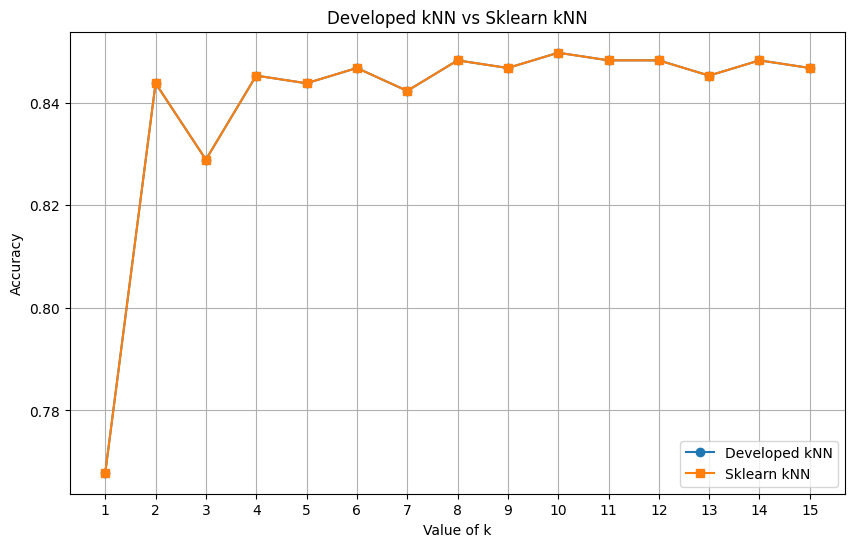


A9
k	Uniform kNN	Weighted kNN
1 	 0.7679 		 0.7679
2 	 0.8438 		 0.7679
3 	 0.8289 		 0.8125
4 	 0.8452 		 0.8214
5 	 0.8438 		 0.8348
6 	 0.8467 		 0.8333
7 	 0.8423 		 0.8363
8 	 0.8482 		 0.8393
9 	 0.8467 		 0.8438
10 	 0.8497 		 0.8452
11 	 0.8482 		 0.8452
12 	 0.8482 		 0.8423
13 	 0.8452 		 0.8438
14 	 0.8482 		 0.8408
15 	 0.8467 		 0.8393


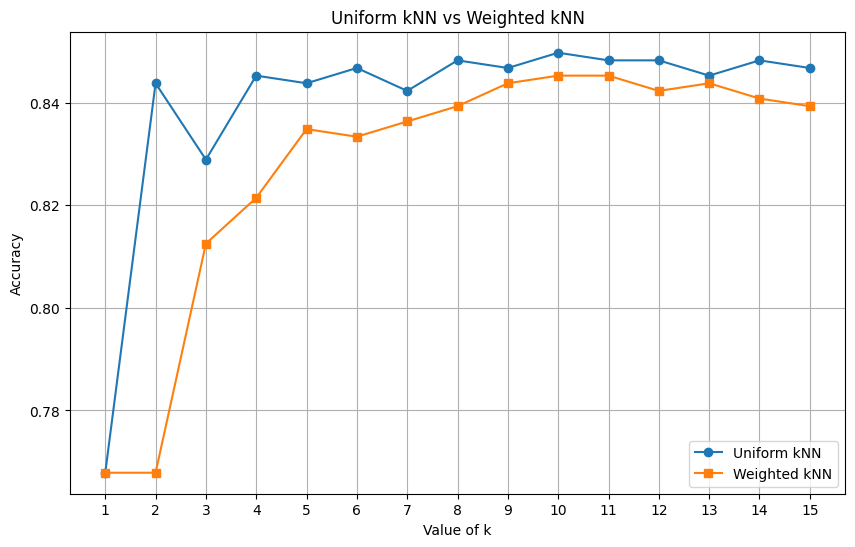

In [21]:
#Function calls of all the above fucntions from A1-A9
file_path = "Lab Session Data.xlsx"


# A1

features, labels = prepare_data(
    file_path
)

x = features.to_numpy(
    dtype=float
)

y = labels.to_numpy()

print("A1")
print("Dataset shape:", x.shape)
print("Classes:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

distance_1 = euclidean_distance(
    x[0],
    x[1]
)

distance_2 = manhattan_distance(
    x[0],
    x[1]
)

distance_3 = minkowski_distance(
    x[0],
    x[1],
    3
)

print("Euclidean distance:", distance_1)
print("Manhattan distance:", distance_2)
print("Minkowski distance:", distance_3)

sample_distances = [
    (5, 0, 1),
    (2, 1, 0),
    (4, 2, 1),
    (1, 3, 0)
]

print(
    "Bubble sort:",
    bubble_sort(sample_distances)
)

print(
    "Selection sort:",
    selection_sort(sample_distances)
)

print(
    "Insertion sort:",
    insertion_sort(sample_distances)
)


# A2

sample_neighbors = [
    (0.2, 0, 1),
    (0.5, 1, 0),
    (0.8, 2, 1)
]

weighted_result = weighted_class_assignment(
    sample_neighbors
)

print("\nA2")
print(
    "Weighted kNN class:",
    weighted_result
)


# A3

x_train, x_test, y_train, y_test = (
    create_train_test_data(
        features,
        labels,
        test_size=0.3,
        random_state=42
    )
)

x_train = x_train.to_numpy(
    dtype=float
)

x_test = x_test.to_numpy(
    dtype=float
)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print("\nA3")
print(
    "Training samples:",
    len(x_train)
)

print(
    "Testing samples:",
    len(x_test)
)

print(
    "Training feature shape:",
    x_train.shape
)

print(
    "Testing feature shape:",
    x_test.shape
)


# A4

sklearn_model = train_sklearn_knn(
    x_train,
    y_train,
    k=3
)

print("\nA4")
print(
    "Sklearn kNN model trained with k = 3"
)


# A5

sklearn_accuracy = calculate_sklearn_accuracy(
    sklearn_model,
    x_test,
    y_test
)

print("\nA5")
print(
    "Sklearn kNN accuracy:",
    sklearn_accuracy
)


# A6

sklearn_predictions = predict_sklearn_knn(
    sklearn_model,
    x_test
)

print("\nA6")
print(
    "First 20 sklearn predictions:"
)

print(
    sklearn_predictions[:20]
)


# A7

custom_model = create_custom_knn(
    x_train,
    y_train,
    k=3,
    metric="euclidean",
    sorting_algorithm="merge"
)

custom_predictions = custom_model.predict(
    x_test
)

custom_accuracy = calculate_accuracy(
    custom_predictions,
    y_test
)

print("\nA7")
print(
    "First 20 developed kNN predictions:"
)

print(
    custom_predictions[:20]
)

print(
    "Developed kNN accuracy:",
    custom_accuracy
)


# A8

k_values = list(
    range(1, 16)
)

custom_accuracy, sklearn_accuracy = (
    compare_knn_accuracy(
        x_train,
        x_test,
        y_train,
        y_test,
        k_values,
        metric="euclidean",
        sorting_algorithm="merge"
    )
)

print("\nA8")

print(
    "k\tDeveloped kNN\tSklearn kNN"
)

for i in range(
    len(k_values)
):
    print(
        k_values[i],
        "\t",
        round(
            custom_accuracy[i],
            4
        ),
        "\t\t",
        round(
            sklearn_accuracy[i],
            4
        )
    )

plot_knn_accuracy(
    k_values,
    custom_accuracy,
    sklearn_accuracy
)


# A9

uniform_accuracy, weighted_accuracy = (
    compare_weighted_accuracy(
        x_train,
        x_test,
        y_train,
        y_test,
        k_values,
        metric="euclidean",
        sorting_algorithm="merge"
    )
)

print("\nA9")

print(
    "k\tUniform kNN\tWeighted kNN"
)

for i in range(
    len(k_values)
):
    print(
        k_values[i],
        "\t",
        round(
            uniform_accuracy[i],
            4
        ),
        "\t\t",
        round(
            weighted_accuracy[i],
            4
        )
    )

plot_weighted_accuracy(
    k_values,
    uniform_accuracy,
    weighted_accuracy
)